oliveira

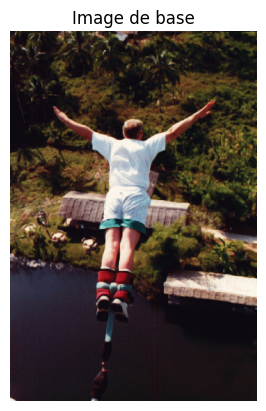

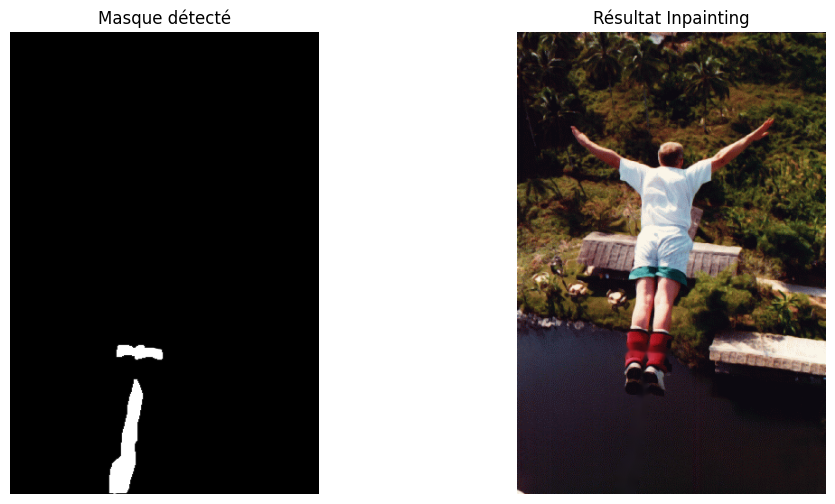

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Chargement
img = cv2.imread('image.png')
mask = cv2.imread('mask.png', 0)

#afficchage image de base
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Image de base")
plt.axis('off')
plt.show()

# Vérification de sécurité
if img is None or mask is None:
    raise FileNotFoundError("L'image ou le masque est introuvable. Vérifie les noms de fichiers !")

# 2. Correction du masque
# Si tu voulais inverser le masque, utilise bitwise_not plutôt que la soustraction
mask = cv2.bitwise_not(mask) 

# 3. Inpainting (On s'assure que les tailles correspondent)
if img.shape[:2] != mask.shape:
    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

dst = cv2.inpaint(img, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

# 4. Affichage sécurisé dans le Notebook
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.title("Masque détecté")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(122)
plt.title("Résultat Inpainting")
# OpenCV utilise BGR, Matplotlib utilise RGB -> on convertit pour les couleurs
plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()